In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Load Geo dataset
df = pd.read_csv('../data/processed/df_geo.csv', parse_dates=['week'])

# Experiment parameters
EXPERIMENT_START = pd.Timestamp('2023-07-03')
TEST_CHANNEL = 'paid_social'
TRUE_LIFT = 0.25  # ground truth we set in data generation

print(df.shape)
print(df.head(10))
print(f"\nRegions: {df['region'].nunique()}")
print(f"Groups: {df['group'].value_counts().to_dict()}")
print(f"Experiment start: {EXPERIMENT_START.date()}")
print(f"Pre-period weeks: {df[df['week'] < EXPERIMENT_START]['week'].nunique()}")
print(f"Post-period weeks: {df[df['week'] >= EXPERIMENT_START]['week'].nunique()}")

(2080, 5)
      region       week    group  paid_social_active   revenue
0  region_00 2022-01-03  control                   1  42788.73
1  region_00 2022-01-10  control                   1  44100.57
2  region_00 2022-01-17  control                   1  42246.72
3  region_00 2022-01-24  control                   1  43961.88
4  region_00 2022-01-31  control                   1  41834.60
5  region_00 2022-02-07  control                   1  47050.45
6  region_00 2022-02-14  control                   1  43813.13
7  region_00 2022-02-21  control                   1  47444.99
8  region_00 2022-02-28  control                   1  44165.67
9  region_00 2022-03-07  control                   1  49651.23

Regions: 20
Groups: {'control': 1040, 'test': 1040}
Experiment start: 2023-07-03
Pre-period weeks: 78
Post-period weeks: 26


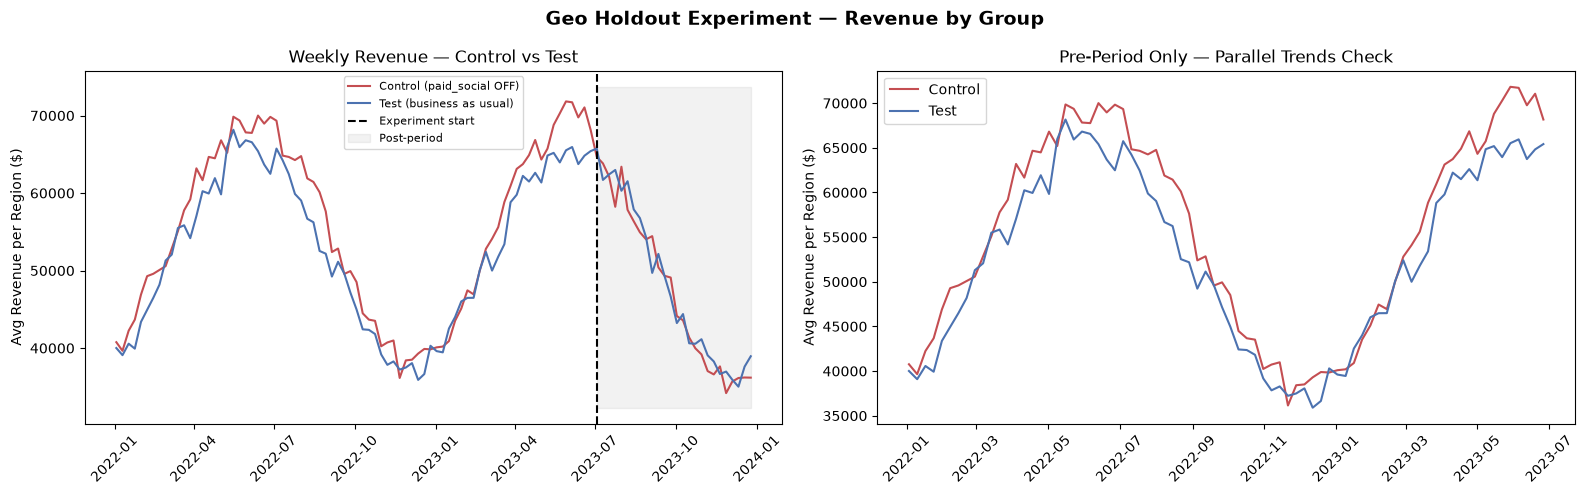

In [2]:
# ── Pre/Post Visualization & Parallel Trends Check ───────────────────────────

# Aggregate weekly revenue by group
df_weekly = (
    df.groupby(['week', 'group'])['revenue']
    .mean()
    .reset_index()
)

df_weekly['period'] = df_weekly['week'].apply(
    lambda x: 'post' if x >= EXPERIMENT_START else 'pre'
)

# Split by group
control_weekly = df_weekly[df_weekly['group'] == 'control']
test_weekly    = df_weekly[df_weekly['group'] == 'test']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Geo Holdout Experiment — Revenue by Group', 
             fontsize=14, fontweight='bold')

# --- Chart 1: Full timeline ---
ax1 = axes[0]
ax1.plot(control_weekly['week'], control_weekly['revenue'],
         label='Control (paid_social OFF)', color='#C44E52', linewidth=1.5)
ax1.plot(test_weekly['week'], test_weekly['revenue'],
         label='Test (business as usual)', color='#4C72B0', linewidth=1.5)
ax1.axvline(x=EXPERIMENT_START, color='black', linestyle='--', linewidth=1.5,
            label='Experiment start')
ax1.fill_betweenx([ax1.get_ylim()[0], ax1.get_ylim()[1]] if ax1.get_ylim()[0] != ax1.get_ylim()[1] else [0, 60000],
                   EXPERIMENT_START, df['week'].max(),
                   alpha=0.1, color='grey', label='Post-period')
ax1.set_title('Weekly Revenue — Control vs Test')
ax1.set_ylabel('Avg Revenue per Region ($)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# --- Chart 2: Pre-period only (parallel trends check) ---
ax2 = axes[1]
pre_control = control_weekly[control_weekly['period'] == 'pre']
pre_test    = test_weekly[test_weekly['period'] == 'pre']

ax2.plot(pre_control['week'], pre_control['revenue'],
         label='Control', color='#C44E52', linewidth=1.5)
ax2.plot(pre_test['week'], pre_test['revenue'],
         label='Test', color='#4C72B0', linewidth=1.5)
ax2.set_title('Pre-Period Only — Parallel Trends Check')
ax2.set_ylabel('Avg Revenue per Region ($)')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/incrementality_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ── Difference-in-Differences Analysis ───────────────────────────────────────

# Add period indicator
df['post'] = (df['week'] >= EXPERIMENT_START).astype(int)
df['is_control'] = (df['group'] == 'control').astype(int)
df['did'] = df['post'] * df['is_control']

# Aggregate to region-week level means
pre_control  = df[(df['post'] == 0) & (df['group'] == 'control')]['revenue'].mean()
pre_test     = df[(df['post'] == 0) & (df['group'] == 'test')]['revenue'].mean()
post_control = df[(df['post'] == 1) & (df['group'] == 'control')]['revenue'].mean()
post_test    = df[(df['post'] == 1) & (df['group'] == 'test')]['revenue'].mean()

# DiD estimate
did_naive  = (post_control - pre_control) - (post_test - pre_test)
did_pct    = did_naive / pre_control

print("=== Difference-in-Differences ===")
print(f"\nPre-period:")
print(f"  Control avg revenue:  ${pre_control:,.0f}")
print(f"  Test avg revenue:     ${pre_test:,.0f}")
print(f"\nPost-period:")
print(f"  Control avg revenue:  ${post_control:,.0f}")
print(f"  Test avg revenue:     ${post_test:,.0f}")
print(f"\nChanges:")
print(f"  Control change:  ${post_control - pre_control:,.0f}")
print(f"  Test change:     ${post_test - pre_test:,.0f}")
print(f"\nDiD estimate:    ${did_naive:,.0f} per region per week")
print(f"DiD as % of pre-period control revenue: {did_pct:.1%}")

# OLS regression for statistical significance
model = smf.ols('revenue ~ post + is_control + did', data=df).fit()
print(f"\n=== OLS Regression ===")
print(f"DiD coefficient: ${model.params['did']:,.0f}")
print(f"P-value:         {model.pvalues['did']:.4f}")
print(f"R²:              {model.rsquared:.4f}")
print(f"\nStatistically significant: {'Yes' if model.pvalues['did'] < 0.05 else 'No'}")

=== Difference-in-Differences ===

Pre-period:
  Control avg revenue:  $55,536
  Test avg revenue:     $52,845

Post-period:
  Control avg revenue:  $47,563
  Test avg revenue:     $48,070

Changes:
  Control change:  $-7,973
  Test change:     $-4,775

DiD estimate:    $-3,198 per region per week
DiD as % of pre-period control revenue: -5.8%

=== OLS Regression ===
DiD coefficient: $-3,198
P-value:         0.0252
R²:              0.0433

Statistically significant: Yes


In [5]:
# ── Corrected Incrementality Results ─────────────────────────────────────────

# True weekly paid_social contribution
true_weekly_effect    = 10000 * TRUE_LIFT  # $2,500
estimated_weekly_effect = incremental_weekly  # $3,198

# Error in absolute terms
error_pct = (estimated_weekly_effect - true_weekly_effect) / true_weekly_effect

print("=== Incrementality Results (Corrected) ===")
print(f"\nDiD estimate:    ${estimated_weekly_effect:,.0f}/week/region")
print(f"Ground truth:    ${true_weekly_effect:,.0f}/week/region")
print(f"Error:           {error_pct:+.1%}")
print(f"P-value:         {model.pvalues['did']:.4f} (significant)")

# For benchmarking — use same scale as MTA/MMM
# Total marketing revenue per week (all channels combined)
total_marketing_weekly = (
    15000 * 0.40 +  # paid_search
    10000 * 0.25 +  # paid_social
     5000 * 0.05 +  # display
     7000 * 0.15    # affiliate
)

incrementality_attribution = estimated_weekly_effect / total_marketing_weekly * 100
ground_truth_attribution   = true_weekly_effect / total_marketing_weekly * 100

print(f"\n=== For Benchmarking (same scale as MTA/MMM) ===")
print(f"Incrementality attribution: {incrementality_attribution:.1f}%")
print(f"Ground truth attribution:   {ground_truth_attribution:.1f}%")

df_incrementality = pd.DataFrame({
    'channel':         ['paid_social'],
    'incrementality':  [round(incrementality_attribution, 2)],
    'ground_truth':    [round(ground_truth_attribution, 2)]
})
print(f"\n{df_incrementality}")

=== Incrementality Results (Corrected) ===

DiD estimate:    $3,198/week/region
Ground truth:    $2,500/week/region
Error:           +27.9%
P-value:         0.0252 (significant)

=== For Benchmarking (same scale as MTA/MMM) ===
Incrementality attribution: 32.6%
Ground truth attribution:   25.5%

       channel  incrementality  ground_truth
0  paid_social           32.63         25.51


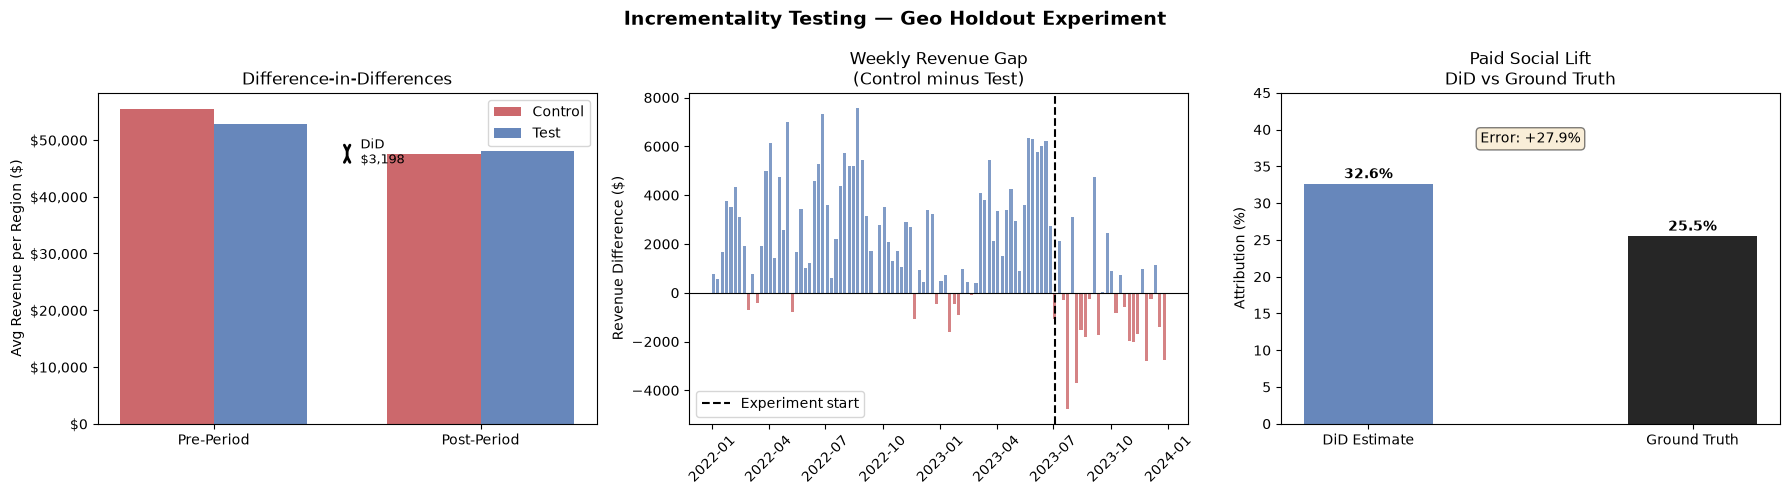

Saved: incrementality_analysis.png


In [6]:
# ── Incrementality Visualization ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Incrementality Testing — Geo Holdout Experiment',
             fontsize=14, fontweight='bold')

# --- Chart 1: DiD visualization ---
ax1 = axes[0]

categories = ['Pre-Period', 'Post-Period']
control_vals = [pre_control, post_control]
test_vals    = [pre_test, post_test]

x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, control_vals, width, 
        label='Control', color='#C44E52', alpha=0.85)
ax1.bar(x + width/2, test_vals, width,
        label='Test', color='#4C72B0', alpha=0.85)

# Annotate DiD
ax1.annotate('', 
             xy=(0.5, post_control), 
             xytext=(0.5, post_test),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax1.text(0.55, (post_control + post_test) / 2,
         f'DiD\n${incremental_weekly:,.0f}',
         fontsize=9, va='center')

ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylabel('Avg Revenue per Region ($)')
ax1.set_title('Difference-in-Differences')
ax1.legend()
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# --- Chart 2: Weekly gap between groups ---
ax2 = axes[1]

merged = control_weekly.merge(
    test_weekly, on='week', suffixes=('_control', '_test')
)
merged['gap'] = merged['revenue_control'] - merged['revenue_test']

colors_gap = ['#C44E52' if g < 0 else '#4C72B0' for g in merged['gap']]
ax2.bar(merged['week'], merged['gap'], color=colors_gap, alpha=0.7, width=5)
ax2.axvline(x=EXPERIMENT_START, color='black', linestyle='--', 
            linewidth=1.5, label='Experiment start')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Weekly Revenue Gap\n(Control minus Test)')
ax2.set_ylabel('Revenue Difference ($)')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# --- Chart 3: Estimated vs True lift ---
ax3 = axes[2]

methods_inc = ['DiD Estimate', 'Ground Truth']
values_inc  = [incrementality_attribution, ground_truth_attribution]
bar_colors  = ['#4C72B0', '#000000']

bars = ax3.bar(methods_inc, values_inc, 
               color=bar_colors, alpha=0.85, width=0.4)

for bar, val in zip(bars, values_inc):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

ax3.set_ylabel('Attribution (%)')
ax3.set_title(f'Paid Social Lift\nDiD vs Ground Truth')
ax3.set_ylim(0, 45)

# Add error annotation
ax3.annotate(f'Error: +{error_pct:.1%}',
             xy=(0.5, 0.85), xycoords='axes fraction',
             ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/processed/incrementality_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: incrementality_analysis.png")